# Real-world Data Wrangling

In [1]:
import pandas as pd
import requests
import json
import csv
import os

os.chdir('..')

We'll be looking at some large tables initially, especially with regard to the number of variables available to us, so I am taking off the DataFrame view window guardrails for columns to make it easier to identify available variables.

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

In this project, you will apply the skills you acquired in the course to gather and wrangle real-world data with two datasets of your choice.

You will retrieve and extract the data, assess the data programmatically and visually, accross elements of data quality and structure, and implement a cleaning strategy for the data. You will then store the updated data into your selected database/data store, combine the data, and answer a research question with the datasets.

Throughout the process, you are expected to:

1. Explain your decisions towards methods used for gathering, assessing, cleaning, storing, and answering the research question
2. Write code comments so your code is more readable

## 1. Gather data

In this section, you will extract data using two different data gathering methods and combine the data. Use at least two different types of data-gathering methods.

### **1.1.** Problem Statement
In this project, I am interested in investigating relationships between health metrics of Americans and the walkability of their communities. There is a lot of discourse around "walkable cities" or "15-minute cities" recently, and I want to explore one aspect of the argument which assumes that people will be healthier if the place they live is easier to walk in than drive in.

The datasets I will be using will include a "National Walkability Index" described by the source as, "a nationwide geographic data resource that ranks block groups according to their relative walkability. The national dataset includes walkability scores for all block groups as well as the underlying attributes that are used to rank the block groups,"

and a 2025 release of the "Food Environment Atlas", which records, "food environment factors—such as store and restaurant proximity, availability of local foods, food and nutrition assistance programs, and community characteristics—interact to influence food choices and diet quality."

**Question:** How will health metrics change as walkability increases?

### **1.2.** Gather at least two datasets using two different data gathering methods

#### **Dataset 1**

**Type:** CSV File

**Method:** The data was gathered by downloading it programmatically through a url using requests `get()` function and saving the content to a local CSV file.

**Dataset variables:** There are 117 variables in the source dataset, listed and described below. Most will be unused and quickly filtered out as we begin our analysis, but we will hold onto STATEFP and COUNTYFP to use as a join key on our other table, and NatWalkInd is the variable we are most interested in for analysis. The full list of variables will be shown after the data is loaded in, as we will need to pull variable descriptors from a different source that will require some cleanup to use.

In [3]:
#1st data gathering and loading method
filename = 'NatWalkInd.csv'
url = "https://edg.epa.gov/EPADataCommons/public/OA/EPA_SmartLocationDatabase_V3_Jan_2021_Final.csv"
response = requests.get(url)
response.raise_for_status()

In [4]:
if os.path.isfile(f"data/{filename}"):
    print(f"The file '{filename}' already exists.")
else:
    with open(f"data/{filename}", mode="wb") as file:
        file.write(response.content)
    print(f"'{filename}' was successfully created.")

The file 'NatWalkInd.csv' already exists.


In [5]:
walkability_df = pd.read_csv(f"data/{filename}")

In [6]:
walkability_df.head()

,OBJECTID,GEOID10,GEOID20,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,CSA,CSA_Name,CBSA,CBSA_Name,CBSA_POP,CBSA_EMP,CBSA_WRK,Ac_Total,Ac_Water,Ac_Land,Ac_Unpr,TotPop,CountHU,HH,P_WrkAge,AutoOwn0,Pct_AO0,AutoOwn1,Pct_AO1,AutoOwn2p,Pct_AO2p,Workers,R_LowWageWk,R_MedWageWk,R_HiWageWk,R_PCTLOWWAGE,TotEmp,E5_Ret,E5_Off,E5_Ind,E5_Svc,E5_Ent,E8_Ret,E8_off,E8_Ind,E8_Svc,E8_Ent,E8_Ed,E8_Hlth,E8_Pub,E_LowWageWk,E_MedWageWk,E_HiWageWk,E_PctLowWage,D1A,D1B,D1C,D1C5_RET,D1C5_OFF,D1C5_IND,D1C5_SVC,D1C5_ENT,D1C8_RET,D1C8_OFF,D1C8_IND,D1C8_SVC,D1C8_ENT,D1C8_ED,D1C8_HLTH,D1C8_PUB,D1D,D1_FLAG,D2A_JPHH,D2B_E5MIX,D2B_E5MIXA,D2B_E8MIX,D2B_E8MIXA,D2A_EPHHM,D2C_TRPMX1,D2C_TRPMX2,D2C_TRIPEQ,D2R_JOBPOP,D2R_WRKEMP,D2A_WRKEMP,D2C_WREMLX,D3A,D3AAO,D3AMM,D3APO,D3B,D3BAO,D3BMM3,D3BMM4,D3BPO3,D3BPO4,D4A,D4B025,D4B050,D4C,D4D,D4E,D5AR,D5AE,D5BR,D5BE,D5CR,D5CRI,D5CE,D5CEI,D5DR,D5DRI,D5DE,D5DEI,D2A_Ranked,D2B_Ranked,D3B_Ranked,D4A_Ranked,NatWalkInd,Shape_Length,Shape_Area
0,1,4.811300e+11,4.811300e+11,48,113,7825,4,206.0,"Dallas-Fort Worth, TX-OK",19100.0,"Dallas-Fort Worth-Arlington, TX",7189384,3545715,3364458,73.595028,0.0,73.595028,73.595028,1202,460.0,423.0,0.549,69,0.163121,39,0.092199,315,0.744681,412,99,122,191,0.240291,66,20,3,0,19,24,20,3,0,15,24,0,4,0,21,27,18,0.318182,6.250422,16.332625,0.896800,0.271757,0.040764,0.000000,0.258170,0.326109,0.271757,0.040764,0.000000,0.203818,0.326109,0.000000,0.054351,0.0,7.147222,0,0.156028,0.886264,0.763386,0.855442,0.662091,0.348912,0.526296,0.585916,0.287128,0.104101,0.276151,6.242424,5.287423e-03,23.534900,0.000000,10.655277,12.879623,115.981747,0.000000,60.873677,8.696240,34.784958,43.481198,362.10,0.0,0.000000,4.33,37.654717,0.003602,433601,303660,135362,53504,0.000398,0.785893,0.000358,0.841299,0.000525,0.184697,0.000476,0.137707,6,14,15,17,14.000000,3110.360820,297836.0831
1,2,4.811300e+11,4.811300e+11,48,113,7825,2,206.0,"Dallas-Fort Worth, TX-OK",19100.0,"Dallas-Fort Worth-Arlington, TX",7189384,3545715,3364458,119.829909,0.0,119.829909,119.214200,710,409.0,409.0,0.466,0,0.000000,168,0.410758,241,0.589242,395,76,107,212,0.192405,25,7,0,3,15,0,7,0,3,13,0,0,2,0,10,4,11,0.400000,3.430799,5.955666,0.209707,0.058718,0.000000,0.025165,0.125824,0.000000,0.058718,0.000000,0.025165,0.109047,0.000000,0.000000,0.016777,0.0,3.640506,0,0.061125,0.835015,0.569986,0.831686,0.554458,0.197047,0.248481,0.271309,0.002033,0.068027,0.119048,15.800000,3.736300e-07,22.893366,0.755137,2.859482,19.278747,80.145600,5.340904,10.681807,10.681807,85.454458,5.340904,718.84,0.0,0.009516,4.33,23.126113,0.006099,386504,272135,236885,90089,0.000355,0.700531,0.000321,0.753958,0.000919,0.323221,0.000801,0.231868,3,10,12,14,10.833333,3519.469110,484945.1466
2,3,4.811300e+11,4.811300e+11,48,113,7825,3,206.0,"Dallas-Fort Worth, TX-OK",19100.0,"Dallas-Fort Worth-Arlington, TX",7189384,3545715,3364458,26.367053,0.0,26.367053,26.367050,737,365.0,329.0,0.811,19,0.057751,143,0.434650,167,0.507599,463,136,189,138,0.293737,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,13.843035,27.951553,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,13.843035,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.367879,0.000000,1.000000,0.000000,0.000000e+00,14.210509,6.128365,2.611430,5.470714,24.272717,24.272717,0.000000,24.272717,0.000000,0.000000,398.31,0.0,0.000000,3.00,72.818150,0.004071,404573,288925,230587,82815,0.000371,0.733281,0.000340,0.800475,0.000894,0.314628,0.000736,0.213146,1,1,7,17,8.333333,1697.091802,106705.9281
3,4,4.811300e+11,4.811300e+11,48,113,7824,1,206.0,"Dallas-Fort Worth, TX-OK",19100.0,"Dallas-Fort Worth-Arlington, TX",7189384,3545715,3364458,119.060687,0.0,119.060687,119.060687,904,384.0,384.0,0.638,0,0.000000,43,0.111979,341,0.888021,431,60,69,302,0.139211,253,26,0,25,47,155,26,0,25,3,155,2,42,0,121,87,45,0.478261,3.225246,7.592767,2.124967,0.218376,0.000000,0.209977,0.394757,1.301857,0.218376,0.000000,0.209977,0.025197,1.301857,0.016798,0.352761,0.0,5

In [7]:
walk_vars = walkability_df.columns.values.tolist()

The descriptors for these variables lives elsewhere in the data source. Of note, the dataset we are using is built off a different dataset which includes these variables amongst others, so we will need to pare down the list of variable descriptors to only match what we have in this dataset.

In [8]:
walk_vars_url = requests.get('https://geodata.epa.gov/arcgis/rest/services/OA/WalkabilityIndex/MapServer/0?f=pjson')
walk_vars_json = json.loads(walk_vars_url.text)

In [9]:
walk_vars_long = walk_vars_json["fields"]

Now we can match the variables to their descriptions in the dataset.

In [10]:
var_matched = []

for v in walk_vars_long:
    if v["name"] in walk_vars:
        var_matched.append({v["name"]:v["alias"]})

Here's the full list of variables, with included descriptions. Again, the only variables of real interest to us in this analysis are the FIPS codes for table joining later, and the NatWalkInd.

In [11]:
var_matched

[{'GEOID10': 'Census block group 12-digit FIPS code (2010)'},
 {'GEOID20': 'Census block group 12-digit FIPS code (2018)'},
 {'STATEFP': 'State FIPS code'},
 {'COUNTYFP': 'County FIPS code'},
 {'TRACTCE': 'Census tract FIPS code in which CBG resides'},
 {'BLKGRPCE': 'Census block group FIPS code in which CBG resides'},
 {'CSA': 'Combined Statistical Area (CSA) Code'},
 {'CSA_Name': 'Name of CSA in which CBG resides'},
 {'CBSA': 'FIPS for Core-Based Statistical Area (CBSA) in which CBG resides'},
 {'CBSA_Name': 'Name of CBSA in which CBG resides'},
 {'CBSA_POP': 'Total population in CBSA'},
 {'CBSA_EMP': 'Total employment in CBSA'},
 {'CBSA_WRK': 'Total number of workers that live in CBSA'},
 {'Ac_Total': 'Total geometric area (acres) of the CBG'},
 {'Ac_Water': 'Total water area (acres)'},
 {'Ac_Land': 'Total land area (acres)'},
 {'Ac_Unpr': 'Total land area (acres) that is not protected from development (i.e., not a park, natural area or conservation area)'},
 {'TotPop': 'Population,

#### Dataset 2

**Type:** CSV File

**Method:** This file was manually downloaded from the data source and uploaded to the local folder.

**Dataset variables:**

- FIPS: State + County FIPS identification numbers
- State: Two-Letter state name abbreviations
- County: Name of county
- Variable_Code: Measurement type identifier
- Value: Value of variable

There are 304 variables within the Variable_Code column, which includes groupings such as tying a factor like a demographic (age, race, income, etc.) or social-program status to grocery store access, per capita availability of certain types of stores or restaurants, farm density, and much more, all of which are related to food access and health in the area listed on the same row. The full list can be reviewed below.  

In [12]:
pd.set_option('display.max_rows', None)
food_vars = pd.read_csv('data/VariableList.csv')
food_vars

,Variable_Name,Category_Name,Category_Code,Subcategory_Name,Variable_Code,Units
0,"Population, low access to store, 2015",Access and Proximity to Foodstore,ACCESS,Overall,LACCESS_POP15,Count
1,"Population, low access to store, 2019",Access and Proximity to Foodstore,ACCESS,Overall,LACCESS_POP19,Count
2,"Population, low access to store (% change), 20...",Access and Proximity to Foodstore,ACCESS,Overall,PCH_LACCESS_POP_15_19,% change
3,"Population, low access to store (%), 2015",Access and Proximity to Foodstore,ACCESS,Overall,PCT_LACCESS_POP15,Percent
4,"Population, low access to store (%), 2019",Access and Proximity to Foodstore,ACCESS,Overall,PCT_LACCESS_POP19,Percent
5,"Low income & low access to store, 2015",Access and Proximity to Foodstore,ACCESS,Household Resources,LACCESS_LOWI15,Count
6,"Low income & low access to store, 2019",Access and Proximity to Foodstore,ACCESS,Household Resources,LACCESS_LOWI19,Count
7,"Low income & low access to store (% change), 2...",Access and Proximity to Foodstore,ACCESS,Household Resources,PCH_LACCESS_LOWI_15_19,% change
8,"Low income & low access to store (%), 2015",Access and Proximity to Foodstore,ACCESS,Household Resources,PCT_LACCESS_LOWI15,Percent
9,"Low income & low access to store (%), 2019",Access and Proximity to Foodstore,ACCESS,Household Resources,PCT_LACCESS_LOWI19,Percent


In [13]:
pd.set_option('display.max_rows', 10)

In [14]:
#2nd data gathering and loading method
food_sec_df = pd.read_csv('data/StateAndCountyData.csv')

In [15]:
food_sec_df.shape

(957753, 5)

In [16]:
food_sec_df.head()

,FIPS,State,County,Variable_Code,Value
0,1001.0,AL,Autauga,LACCESS_POP15,18092.66135
1,1001.0,AL,Autauga,LACCESS_POP19,18503.22551
2,1001.0,AL,Autauga,PCH_LACCESS_POP_15_19,2.26923
3,1001.0,AL,Autauga,PCT_LACCESS_POP15,33.15435
4,1001.0,AL,Autauga,PCT_LACCESS_POP19,33.90670


## 2. Assess data

### Quality Issue 1: FIPS codes stored as numerical values, missing leading zeros.
Federal Information Processing Standards (FIPS) numbers are often used to designate geographic locations and regions in datasets concerning the United States. These numbers, much like zip codes, are qualitative rather than quantitative values, so we want them to be parsed as a string data type rather than a numerical data type. Let's see how our datasets handle these values:

In [17]:
#Inspecting the dataframe visually
food_sec_df.head(1)

,FIPS,State,County,Variable_Code,Value
0,1001.0,AL,Autauga,LACCESS_POP15,18092.66135


In [18]:
walkability_df[(walkability_df['STATEFP'] < 10) & (walkability_df['COUNTYFP'] < 100)][['STATEFP', 'COUNTYFP']].head(1)

,STATEFP,COUNTYFP
21143,1,73


In [19]:
#Inspecting the dataframe programmatically
walkability_df[['STATEFP', 'COUNTYFP']].describe(), walkability_df[['STATEFP', 'COUNTYFP']].info()

<class 'pandas.DataFrame'>
RangeIndex: 220740 entries, 0 to 220739
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   STATEFP   220740 non-null  int64
 1   COUNTYFP  220740 non-null  int64
dtypes: int64(2)
memory usage: 3.4 MB


(             STATEFP       COUNTYFP
 count  220740.000000  220740.000000
 mean       28.623190      85.697449
 std        16.386075      98.818946
 min         1.000000       1.000000
 25%        13.000000      29.000000
 50%        29.000000      61.000000
 75%        42.000000     109.000000
 max        78.000000     840.000000,
 None)

In [20]:
food_sec_df['FIPS'].describe(), food_sec_df[['FIPS']].info()

<class 'pandas.DataFrame'>
RangeIndex: 957753 entries, 0 to 957752
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   FIPS    957278 non-null  float64
dtypes: float64(1)
memory usage: 7.3 MB


(count    957278.000000
 mean      30343.740874
 std       15183.939474
 min        1001.000000
 25%       18169.000000
 50%       29171.000000
 75%       45079.000000
 max       56045.000000
 Name: FIPS, dtype: float64,
 None)

**Issue and justification:** In both datasets, we can see that the column(s) containing FIPS values use numerical data types, demonstrated visually by the decimal point and single floating point of accuracy in dataset 2, and programmatically by the Dtypes of `int64` and `float64` in the `.info()` tables, and the ability to give statistical breakpoints in the `.describe()` table. Looking at the second dataset makes it clear that there will not be the correct number of digits in any of the FIPS codes in that column simply due to the floating point causing larger numbers of digits than expected; a similar discrepency in digit length is not so obvious for the first datset unless we specifically look for values that would have leading zeros - once we do, we notice the values have fewer digits than expected because leading zeros have been dropped. This will make it difficult for us to accurately tie FIPS and locations together, especially when comparing to the data sets. Given that FIPS is how we want to join these tables later on, we want to make sure the FIPS formatting is consistent between both datasets and converted to strings.

### Quality Issue 2: FIPS State + County values stored in separate columns in Dataset 1, concatenated in one column in Dataset 2.
FIPS codes exist for multiple levels of area designation, with the two most common being State and County level. State FIPS codes are 2-digits long, while County FIPS codes are 3-digits long. Let's see how these values are stored in our datasets:

In [21]:
#Inspecting the dataframe visually
food_sec_df[['FIPS']].head(1)

,FIPS
0,1001.0


In [22]:
#Inspecting the dataframe programmatically
state_fp = walkability_df['STATEFP'].tolist()
sfp_lens = []
for sf in state_fp:
    if len(str(sf)) not in sfp_lens:
        sfp_lens.append(len(str(sf)))
    else:
        continue

In [23]:
county_fp = walkability_df['COUNTYFP'].tolist()
cfp_lens = []
for cf in county_fp:
    if len(str(cf)) not in cfp_lens:
        cfp_lens.append(len(str(cf)))
    else:
        continue

In [24]:
sfp_lens, cfp_lens #These lists show how many digits the state and county FIPS codes use respectively within the first dataset

([2, 1], [3, 2, 1])

In [25]:
sc_fp = food_sec_df['FIPS'].tolist()
sc_fp_lens = []
for scf in sc_fp:
    if len(str(scf)) not in sc_fp_lens:
        sc_fp_lens.append(len(str(scf)))
    else:
        continue

In [26]:
sc_fp_lens #This list shows how many digits the FIPS codes use in the second dataset

[6, 7, 3]

**Issue and justification:** Our two datasets store their FIPS data quite differently. Simple visual inspection of the tables demonstrates that there are clear differences in the storage of FIPS codes in each dataset, with the first dataset splitting the FIPS codes for state and county into two columns and the second combining them into one value/column. For both datasets, we can loop through the FIPS values to quickly find out what kind of variation in digit length exists in these FIPS codes. In dataset 1, the state and county FIPS codes each have their own column, and when we look at the length of the codes we can see some variation - instead of state codes consistently being 2-digit, some are 1-digit; county codes range from 1 to 3-digits. In dataset 2, the state and county codes are combined to make one value in a ST+CTY format which should make 5 digit FIPS codes, but instead we have 6, 7, and 3-digit codes in that column. In this state, we will not be able to match and join the tables together for our final analysis.

There are a couple items we can point to in order to explain these variances. The first would be a compound effect of our first issue, which is that numerical data types don't store leading zeros, so that explains why our first dataset has lower digit values than expected. On the other side, because dataset 2 stores FIPS codes as floats, there are always two extra digits (`.0`) at the end of each code, making them longer than expected. Without the floating point, these would be 4 or 5-digit codes, again with variance because state codes with floating zeros would drop those leading zeros.

The 3-digit codes in dataset 2 are unexpected, until you look back at the `.info()` table and realize there are almost 500 rows with missing values in the dataset. The "3-digit code" is likely `NaN` values. We can confirm this as well as identify the culprit rows with a small piece of code filtering and counting the rows with null FIPS codes.  

In [27]:
food_sec_df[food_sec_df['FIPS'].isnull() == True][['State', 'County']].value_counts()

State  County               
AK     Aleutian Islands Area    95
       Anchorage Area           95
       Fairbanks Area           95
       Juneau Area              95
       Kenai Peninsula Area     95
Name: count, dtype: int64

There are 5 Alaskan regions covering 95 rows each that are missing their FIPS codes in this dataset. We will likely have to do some more investigation to determine if these can be assigned codes or if we need to drop them before conducting our analysis.

### Tidiness Issue 1: Variable_Code column in Dataset 2 contains multiple variables in one column, should be split into multiple columns/tables.

As stated in the above description of the second dataset, there is a column `Variable_Code` which describes the measurement being shown in the row, and there are 304 measurements to choose from for almost each geographic area denoted.

In [28]:
#Inspecting the dataframe visually
food_sec_df[['Variable_Code']]

,Variable_Code
0,LACCESS_POP15
1,LACCESS_POP19
2,PCH_LACCESS_POP_15_19
3,PCT_LACCESS_POP15
4,PCT_LACCESS_POP19
...,...
957748,SODATAX_STORES14
957749,SODATAX_VENDM14
957750,CHIPSTAX_STORES14
957751,CHIPSTAX_VENDM14


In [29]:
#Inspecting the dataframe programmatically
len(food_sec_df['Variable_Code'].value_counts())

304

**Issue and justification:** Visual inspection of the table and the relevant variable description list above show the intense breadth of variables and measurements within one table, let alone one column, programmatic inspection of the length of list of variables proves there is more than one variable in the column which goes against tidiness best practices. There are variables measuring raw value, percentages, different years, different products, different demographics, etc. These variables need to be given their own columns each at the very least in order to make a tidy dataset. 

### Tidiness Issue 2: Dataset 1 is wide, contains multiple observational units, should be split into multiple tables.

In [30]:
#Inspecting the dataframe visually
walkability_df.head(1)

,OBJECTID,GEOID10,GEOID20,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,CSA,CSA_Name,CBSA,CBSA_Name,CBSA_POP,CBSA_EMP,CBSA_WRK,Ac_Total,Ac_Water,Ac_Land,Ac_Unpr,TotPop,CountHU,HH,P_WrkAge,AutoOwn0,Pct_AO0,AutoOwn1,Pct_AO1,AutoOwn2p,Pct_AO2p,Workers,R_LowWageWk,R_MedWageWk,R_HiWageWk,R_PCTLOWWAGE,TotEmp,E5_Ret,E5_Off,E5_Ind,E5_Svc,E5_Ent,E8_Ret,E8_off,E8_Ind,E8_Svc,E8_Ent,E8_Ed,E8_Hlth,E8_Pub,E_LowWageWk,E_MedWageWk,E_HiWageWk,E_PctLowWage,D1A,D1B,D1C,D1C5_RET,D1C5_OFF,D1C5_IND,D1C5_SVC,D1C5_ENT,D1C8_RET,D1C8_OFF,D1C8_IND,D1C8_SVC,D1C8_ENT,D1C8_ED,D1C8_HLTH,D1C8_PUB,D1D,D1_FLAG,D2A_JPHH,D2B_E5MIX,D2B_E5MIXA,D2B_E8MIX,D2B_E8MIXA,D2A_EPHHM,D2C_TRPMX1,D2C_TRPMX2,D2C_TRIPEQ,D2R_JOBPOP,D2R_WRKEMP,D2A_WRKEMP,D2C_WREMLX,D3A,D3AAO,D3AMM,D3APO,D3B,D3BAO,D3BMM3,D3BMM4,D3BPO3,D3BPO4,D4A,D4B025,D4B050,D4C,D4D,D4E,D5AR,D5AE,D5BR,D5BE,D5CR,D5CRI,D5CE,D5CEI,D5DR,D5DRI,D5DE,D5DEI,D2A_Ranked,D2B_Ranked,D3B_Ranked,D4A_Ranked,NatWalkInd,Shape_Length,Shape_Area
0,1,4.811300e+11,4.811300e+11,48,113,7825,4,206.0,"Dallas-Fort Worth, TX-OK",19100.0,"Dallas-Fort Worth-Arlington, TX",7189384,3545715,3364458,73.595028,0.0,73.595028,73.595028,1202,460.0,423.0,0.549,69,0.163121,39,0.092199,315,0.744681,412,99,122,191,0.240291,66,20,3,0,19,24,20,3,0,15,24,0,4,0,21,27,18,0.318182,6.250422,16.332625,0.8968,0.271757,0.040764,0.0,0.25817,0.326109,0.271757,0.040764,0.0,0.203818,0.326109,0.0,0.054351,0.0,7.147222,0,0.156028,0.886264,0.763386,0.855442,0.662091,0.348912,0.526296,0.585916,0.287128,0.104101,0.276151,6.242424,0.005287,23.5349,0.0,10.655277,12.879623,115.981747,0.0,60.873677,8.69624,34.784958,43.481198,362.1,0.0,0.0,4.33,37.654717,0.003602,433601,303660,135362,53504,0.000398,0.785893,0.000358,0.841299,0.000525,0.184697,0.000476,0.137707,6,14,15,17,14.0,3110.36082,297836.0831


In [31]:
#Inspecting the dataframe programmatically
len(walkability_df.columns.value_counts())

117

**Issue and justification:** Looking at the header of this dataset and reading the deescriptions for the variables, we see this dataset measures geographic area, population, car ownership, employment statistics, and more. Programmatic inspection totals the number of columns at 117, even filtering out some of the identifier columns at the front leaves us with over 100 variables of various types in one table. We stated earlier that this table only has a few columns that we want to keep, so this should be resolved quickly once we start cleaning.

## 3. Clean data
Clean the data to solve the 4 issues corresponding to data quality and tidiness found in the assessing step. **Make sure you include justifications for your cleaning decisions.**

After the cleaning for each issue, please use **either** the visually or programatical method to validate the cleaning was succesful.

At this stage, you are also expected to remove variables that are unnecessary for your analysis and combine your datasets. Depending on your datasets, you may choose to perform variable combination and elimination before or after the cleaning stage. Your dataset must have **at least** 4 variables after combining the data.

In [32]:
# Make copies of the datasets to ensure the raw dataframes are not impacted
walk_clean_df = walkability_df.copy()
food_clean_df = food_sec_df.copy()

### **Quality Issue 1: FIPS codes stored as numerical values, missing leading zeros.**

In [33]:
# First, we need to change the data types of these columns to be strings instead of numerical types.
walk_clean_df['STATEFP'] = walk_clean_df['STATEFP'].astype('string')
walk_clean_df['COUNTYFP'] = walk_clean_df['COUNTYFP'].astype('string')
food_clean_df['FIPS'] = food_clean_df['FIPS'].astype('string')

In [34]:
# Next, we need to add leading zeros to those FIPS codes that are missing them, and trim floating points from dataset 2's FIPS codes.
# Starting with dataset 1:
walk_clean_df['STATEFP'] = walk_clean_df['STATEFP'].str.zfill(2)
walk_clean_df['COUNTYFP'] = walk_clean_df['COUNTYFP'].str.zfill(3)

In [35]:
# Now for dataset 2, starting with trimming the floating point and then adding floating zeros
food_clean_df['FIPS'] = food_clean_df['FIPS'].str.replace(r'\.0$', '', regex=True)
food_clean_df['FIPS'] = food_clean_df['FIPS'].str.zfill(5)

There will still be 4-length entries in this dataset after this cleaning, representing those null values we found earlier with `<NA>` values. After reviewing the documentation, I feel comfortable removing those values as they for various reasons would not be applicable to this study, not the least of which being that the values for these entries are used to communicate exclusion codes rather than actual measurements.

In [36]:
food_clean_df.dropna(inplace=True)

In [37]:
# FILL IN - Validate the cleaning was successful
walk_clean_df[['STATEFP','COUNTYFP']].info(), food_clean_df[['FIPS']].info()

<class 'pandas.DataFrame'>
RangeIndex: 220740 entries, 0 to 220739
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   STATEFP   220740 non-null  string
 1   COUNTYFP  220740 non-null  string
dtypes: string(2)
memory usage: 3.4 MB
<class 'pandas.DataFrame'>
Index: 957278 entries, 0 to 957752
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   FIPS    957278 non-null  string
dtypes: string(1)
memory usage: 14.6 MB


(None, None)

All FIPS columns are now strings. Now let's check to see if we were able to get the correct digit lengths:

In [38]:
clean_sc_fp = food_clean_df['FIPS'].tolist()
clean_sc_fp_lens = []
for scf in clean_sc_fp:
    if len(scf) not in clean_sc_fp_lens:
        clean_sc_fp_lens.append(len(scf))
    else:
        continue

In [39]:
clean_sc_fp_lens

[5]

In [40]:
clean_state_fp = walk_clean_df['STATEFP'].tolist()
clean_sfp_lens = []
for sf in clean_state_fp:
    if len(str(sf)) not in clean_sfp_lens:
        clean_sfp_lens.append(len(str(sf)))
    else:
        continue

clean_county_fp = walk_clean_df['COUNTYFP'].tolist()
clean_cfp_lens = []
for cf in clean_county_fp:
    if len(str(cf)) not in clean_cfp_lens:
        clean_cfp_lens.append(len(str(cf)))
    else:
        continue

In [41]:
clean_sfp_lens, clean_cfp_lens

([2], [3])

State + County codes are 5, State codes are 2, County codes are 3. All looks to be in order.

**Justification:** My cleaning steps here included changing the data types of the columns holding FIPS values, and then performing strang manipulations using `.zfill()` and regex to add leading zeros back to the codes and drop floating point additions to codes read in as floats, respectively. The FIPS codes need to be strings so they can be properly formatted for copmparison later since they will be the matching values these datasets are joined on later. `.zfill()` from the pandas library offers a simple way to ensure all values match the number of digits they are supposed to, adding leading zeros when they come up short, and basic string replacement using a regex expression to trim the floating point off also ensures consistent formatting changes to all values affected. 

### **Quality Issue 2: FIPS State + County values stored in separate columns in Dataset 1, concatenated in one column in Dataset 2.**

In [42]:
# Having both codes combined into one value/column seems simpler than keeping them separated, so I will concatenate the STATEFP and COUNTYFP columns into one SC_FIPS column
walk_clean_df['SC_FIPS'] = walk_clean_df['STATEFP'] + walk_clean_df['COUNTYFP']

In [43]:
#Validate the cleaning was successful
walk_clean_df[['SC_FIPS']]

,SC_FIPS
0,48113
1,48113
2,48113
3,48113
4,48113
...,...
220735,78030
220736,78030
220737,78030
220738,78030


**Justification:** My cleaning step for this issue was to simply combine the two FIPS columns into one to match the formatting of the other dataset. This will allow me to join the two datasets easily using one column with no additional modifications.

### **Tidiness Issue 1: Variable_Code column in Dataset 2 contains multiple variables in one column, should be split into multiple columns/tables.**

For this project, I am only interested in the variables in dataset 2 which concern health metrics. In this table are 4 such variables:

- `PCT_DIABETES_ADULTS15`
- `PCT_DIABETES_ADULTS19`
- `PCT_OBESE_ADULTS17`
- `PCT_OBESE_ADULTS22`

These measure the percent of adults in the given area who had diabetes (measured in 2015 and 2019) or were considered obese\* (measured in 2017 and 2022).

There are in fact two tidiness issues that we can address here, as once we fix the multiple variable in a column issue for the whole dataset we run into the issue of the datasety being over 300 columns wide. Instead of making a massively wide dataset, we will simply cut the table down to the category of variables we care about to start, effectively solving both tidiness issues at once.

\* A note: The obesity measurements are statewide rather than by county, so all counties within a state will show the same obesity measurements. This will be reflected on at the end of the project.

In [44]:
# First I want to make a list of the variables and pull the names of the ones I want to make columns so I can assign them later
food_clean_columns = food_clean_df['Variable_Code'].unique().tolist()

In [45]:
# This list will store all my desired column names, starting with the identifier columns.
# The next cells will programmatically pull the health variable names I want and append them to this list of column names.
food_wide_cols  = ['FIPS', 'State', 'County']

In [46]:
health_cols = food_vars[food_vars['Subcategory_Name'] == 'Health']['Variable_Code'].tolist()

In [47]:
for _ in health_cols:
    food_wide_cols.append(_)

food_wide_cols

['FIPS',
 'State',
 'County',
 'PCT_DIABETES_ADULTS15',
 'PCT_DIABETES_ADULTS19',
 'PCT_OBESE_ADULTS17',
 'PCT_OBESE_ADULTS22']

With my column names set, now I will perform a series of table filters and merges. The goal is to get all of the variables on the same row as their respective locations.

In [48]:
# I will create four dataframes, each a subtable of the main dataset specific to the variable I am trying to isolate.
# The dataframes other than the first made will not include the state and county names, just to reduce the number of
# columns I will have to drop later.
# I am also dropping and resetting the index on each table, which will make merging much simpler in the next step.
food_clean_db15 = food_clean_df[food_clean_df['Variable_Code'] == 'PCT_DIABETES_ADULTS15'].reset_index(drop=True)
food_clean_db19 = food_clean_df[food_clean_df['Variable_Code'] == 'PCT_DIABETES_ADULTS19'][['FIPS', 'Variable_Code', 'Value']].reset_index(drop=True)
food_clean_ob17 = food_clean_df[food_clean_df['Variable_Code'] == 'PCT_OBESE_ADULTS17'][['FIPS', 'Variable_Code', 'Value']].reset_index(drop=True)
food_clean_ob22 = food_clean_df[food_clean_df['Variable_Code'] == 'PCT_OBESE_ADULTS22'][['FIPS', 'Variable_Code', 'Value']].reset_index(drop=True)

In [49]:
# I will perform three dataframe merges, all on the 'FIPS' column.
# The first merge will create one combined table of diabetes data from both years, the second merge will do the same for obesity data.
# The third merge will put the two together, and we should have all the variables in their own column by the end.
food_clean_db = pd.merge(food_clean_db15, food_clean_db19, on='FIPS')
food_clean_ob = pd.merge(food_clean_ob17, food_clean_ob22, on='FIPS')
food_clean_health = pd.merge(food_clean_db, food_clean_ob, on='FIPS')

In [50]:
# We can visually inspect to see if the merges occurred correctly
food_clean_health

,FIPS,State,County,Variable_Code_x_x,Value_x_x,Variable_Code_y_x,Value_y_x,Variable_Code_x_y,Value_x_y,Variable_Code_y_y,Value_y_y
0,01001,AL,Autauga,PCT_DIABETES_ADULTS15,9.1,PCT_DIABETES_ADULTS19,9.6,PCT_OBESE_ADULTS17,36.3,PCT_OBESE_ADULTS22,38.3
1,01003,AL,Baldwin,PCT_DIABETES_ADULTS15,8.6,PCT_DIABETES_ADULTS19,7.9,PCT_OBESE_ADULTS17,36.3,PCT_OBESE_ADULTS22,38.3
2,01005,AL,Barbour,PCT_DIABETES_ADULTS15,12.7,PCT_DIABETES_ADULTS19,11.3,PCT_OBESE_ADULTS17,36.3,PCT_OBESE_ADULTS22,38.3
3,01007,AL,Bibb,PCT_DIABETES_ADULTS15,9.9,PCT_DIABETES_ADULTS19,10.2,PCT_OBESE_ADULTS17,36.3,PCT_OBESE_ADULTS22,38.3
4,01009,AL,Blount,PCT_DIABETES_ADULTS15,9.9,PCT_DIABETES_ADULTS19,9.5,PCT_OBESE_ADULTS17,36.3,PCT_OBESE_ADULTS22,38.3
...,...,...,...,...,...,...,...,...,...,...,...
3139,56037,WY,Sweetwater,PCT_DIABETES_ADULTS15,8.3,PCT_DIABETES_ADULTS19,7.6,PCT_OBESE_ADULTS17,28.8,PCT_OBESE_ADULTS22,34.3
3140,56039,WY,Teton,PCT_DIABETES_ADULTS15,4.1,PCT_DIABETES_ADULTS19,4.2,PCT_OBESE_ADULTS17,28.8,PCT_OBESE_ADULTS22,34.3
3141,56041,WY,Uinta,PCT_DIABETES_ADULTS15,9.3,PCT_DIABETES_ADULTS19,7.3,PCT_OBESE_ADULTS17,28.8,PCT_OBESE_ADULTS22,34.3
3142,56043,WY,Washakie,PCT_DIABETES_ADULTS15,8.6,PCT_DIABETES_ADULTS19,8.8,PCT_OBESE_ADULTS17,28.8,PCT_OBESE_ADULTS22,34.3


This looks great. Now I am going to set up one more dataframe, this one will not have any `Variable_Code` columns and the name of the variable being measured will instead be in the header, with its respective values sitting in the rows below it.

In [51]:
health_clean_df = food_clean_health[['FIPS', 'State', 'County', 'Value_x_x', 'Value_y_x', 'Value_x_y', 'Value_y_y']]

In [52]:
# With the data set up, now I can use that list of column names from the top of this section to appropriately name the columns.
health_clean_df.columns = food_wide_cols

Now let's view the table and confirm visually that the changes were successful, comparing a few examples from the head and tail of the original data with the new frame.

In [53]:
health_clean_df

,FIPS,State,County,PCT_DIABETES_ADULTS15,PCT_DIABETES_ADULTS19,PCT_OBESE_ADULTS17,PCT_OBESE_ADULTS22
0,01001,AL,Autauga,9.1,9.6,36.3,38.3
1,01003,AL,Baldwin,8.6,7.9,36.3,38.3
2,01005,AL,Barbour,12.7,11.3,36.3,38.3
3,01007,AL,Bibb,9.9,10.2,36.3,38.3
4,01009,AL,Blount,9.9,9.5,36.3,38.3
...,...,...,...,...,...,...,...
3139,56037,WY,Sweetwater,8.3,7.6,28.8,34.3
3140,56039,WY,Teton,4.1,4.2,28.8,34.3
3141,56041,WY,Uinta,9.3,7.3,28.8,34.3
3142,56043,WY,Washakie,8.6,8.8,28.8,34.3


In [54]:
food_clean_df[food_clean_df['Variable_Code'] == 'PCT_DIABETES_ADULTS15'].head(3), food_clean_df[food_clean_df['Variable_Code'] == 'PCT_DIABETES_ADULTS15'].tail(3)

(         FIPS State   County          Variable_Code  Value
 374298  01001    AL  Autauga  PCT_DIABETES_ADULTS15    9.1
 374309  01003    AL  Baldwin  PCT_DIABETES_ADULTS15    8.6
 374320  01005    AL  Barbour  PCT_DIABETES_ADULTS15   12.7,
          FIPS State    County          Variable_Code  Value
 408849  56041    WY     Uinta  PCT_DIABETES_ADULTS15    9.3
 408860  56043    WY  Washakie  PCT_DIABETES_ADULTS15    8.6
 408871  56045    WY    Weston  PCT_DIABETES_ADULTS15    8.0)

In [55]:
food_clean_df[food_clean_df['Variable_Code'] == 'PCT_DIABETES_ADULTS19'].head(3), food_clean_df[food_clean_df['Variable_Code'] == 'PCT_DIABETES_ADULTS19'].tail(3)

(         FIPS State   County          Variable_Code  Value
 374299  01001    AL  Autauga  PCT_DIABETES_ADULTS19    9.6
 374310  01003    AL  Baldwin  PCT_DIABETES_ADULTS19    7.9
 374321  01005    AL  Barbour  PCT_DIABETES_ADULTS19   11.3,
          FIPS State    County          Variable_Code  Value
 408850  56041    WY     Uinta  PCT_DIABETES_ADULTS19    7.3
 408861  56043    WY  Washakie  PCT_DIABETES_ADULTS19    8.8
 408872  56045    WY    Weston  PCT_DIABETES_ADULTS19    8.1)

In [56]:
food_clean_df[food_clean_df['Variable_Code'] == 'PCT_OBESE_ADULTS17'].head(3), food_clean_df[food_clean_df['Variable_Code'] == 'PCT_OBESE_ADULTS17'].tail(3)

(         FIPS State   County       Variable_Code  Value
 374300  01001    AL  Autauga  PCT_OBESE_ADULTS17   36.3
 374311  01003    AL  Baldwin  PCT_OBESE_ADULTS17   36.3
 374322  01005    AL  Barbour  PCT_OBESE_ADULTS17   36.3,
          FIPS State    County       Variable_Code  Value
 408851  56041    WY     Uinta  PCT_OBESE_ADULTS17   28.8
 408862  56043    WY  Washakie  PCT_OBESE_ADULTS17   28.8
 408873  56045    WY    Weston  PCT_OBESE_ADULTS17   28.8)

In [57]:
food_clean_df[food_clean_df['Variable_Code'] == 'PCT_OBESE_ADULTS22'].head(3), food_clean_df[food_clean_df['Variable_Code'] == 'PCT_OBESE_ADULTS22'].tail(3)

(         FIPS State   County       Variable_Code  Value
 374301  01001    AL  Autauga  PCT_OBESE_ADULTS22   38.3
 374312  01003    AL  Baldwin  PCT_OBESE_ADULTS22   38.3
 374323  01005    AL  Barbour  PCT_OBESE_ADULTS22   38.3,
          FIPS State    County       Variable_Code  Value
 408852  56041    WY     Uinta  PCT_OBESE_ADULTS22   34.3
 408863  56043    WY  Washakie  PCT_OBESE_ADULTS22   34.3
 408874  56045    WY    Weston  PCT_OBESE_ADULTS22   34.3)

All the values seem to be lining up, so this dataset is ready to use.

**Justification:** There were several options I could have used to complete this cleaning, and I tried many of them before landing on creating sub-tables and merging them. I used this method because it allowed me to most easily verify that values were being assigned and aligned correctly, and reduced the number of rows I would need to manually drop. The resulting dataframe is now ready to be merged with the other dataset when it is ready.

### **Tidiness Issue 2: Dataset 1 is wide, contains multiple observational units, should be split into multiple tables.**

The fix for the issue above was very involved, this one will be significantly less so since the table is already set up with one variable per column. There is one thing to address, which is that dataset 1 actually has a finer grain of measurement compared to dataset 2. dataset 2's granularity stops at the county level, but dataset 1 goes down to census block level, which is the smallest geographical area used by the U.S. Census Bureau when tabulating collected data. As a result, we have multiple entries per FIPS code, and we want to condense that information to the county level to it matches up with dataset 2's scope.

The way we will address the tidiness and granularity issues will all happen in one line of code, which will store a filtered dataframe containing only FIPS and walkability index values, which will be grouped by FIPS and the average walkability value of all entries in a county will be recorded for that FIPS code.

In [58]:
walk_ind_df = walk_clean_df[['SC_FIPS', 'NatWalkInd']].groupby(by='SC_FIPS').mean()

Let's look at the reuslts:

In [59]:
walk_ind_df

,NatWalkInd
SC_FIPS,
01001,5.234375
01003,6.450355
01005,5.188406
01007,5.033333
01009,4.666667
...,...
72151,3.402778
72153,4.559524
78010,4.201550


**Justification:** Filtering the original table to just the FIPS and walkability scores satisfies the tidiness goal of one observational unit per table, and the table has been made shorter as a result of our need to aggregate data.

### **Remove unnecessary variables and combine datasets**

In [60]:
# Dataset 1 will be my left table, Dataset 2 my right table. Since the FIPS columns are named differently, I will need to name them seperately in the .merge() parameters.
walk_health_df = pd.merge(left=walk_ind_df, right=health_clean_df, left_on='SC_FIPS', right_on='FIPS')

The merge results in columns being in a less than desirable order for readability, so I am opting to reorder the columns using `.reindex()`.

In [61]:
walk_health_df = walk_health_df.reindex(columns=['FIPS', 'State', 'County', 'NatWalkInd', 'PCT_DIABETES_ADULTS15', 'PCT_DIABETES_ADULTS19', 'PCT_OBESE_ADULTS17', 'PCT_OBESE_ADULTS22'])

In [62]:
walk_health_df

,FIPS,State,County,NatWalkInd,PCT_DIABETES_ADULTS15,PCT_DIABETES_ADULTS19,PCT_OBESE_ADULTS17,PCT_OBESE_ADULTS22
0,01001,AL,Autauga,5.234375,9.1,9.6,36.3,38.3
1,01003,AL,Baldwin,6.450355,8.6,7.9,36.3,38.3
2,01005,AL,Barbour,5.188406,12.7,11.3,36.3,38.3
3,01007,AL,Bibb,5.033333,9.9,10.2,36.3,38.3
4,01009,AL,Blount,4.666667,9.9,9.5,36.3,38.3
...,...,...,...,...,...,...,...,...
3137,56037,WY,Sweetwater,7.210784,8.3,7.6,28.8,34.3
3138,56039,WY,Teton,7.833333,4.1,4.2,28.8,34.3
3139,56041,WY,Uinta,6.979167,9.3,7.3,28.8,34.3
3140,56043,WY,Washakie,7.812500,8.6,8.8,28.8,34.3


In further inspecting the data, I found several entries in the health data for the second recorded year of each metric which have values signifying they are meant to be excluded:

In [63]:
walk_health_df[walk_health_df['PCT_DIABETES_ADULTS15'] < 0], walk_health_df[walk_health_df['PCT_DIABETES_ADULTS19'] < 0], walk_health_df[walk_health_df['PCT_OBESE_ADULTS17'] < 0], walk_health_df[walk_health_df['PCT_OBESE_ADULTS22'] < 0]

(Empty DataFrame
 Columns: [FIPS, State, County, NatWalkInd, PCT_DIABETES_ADULTS15, PCT_DIABETES_ADULTS19, PCT_OBESE_ADULTS17, PCT_OBESE_ADULTS22]
 Index: [],
        FIPS State          County  NatWalkInd  PCT_DIABETES_ADULTS15  \
 92    02261    AK  Valdez-Cordova    5.439394                    8.4   
 1774  34001    NJ        Atlantic   12.189312                   10.0   
 1775  34003    NJ          Bergen   13.515171                    6.6   
 1776  34005    NJ      Burlington    9.813620                    8.0   
 1777  34007    NJ          Camden   12.821553                    8.9   
 ...     ...   ...             ...         ...                    ...   
 1790  34033    NJ           Salem    9.456667                   10.3   
 1791  34035    NJ        Somerset    9.014733                    7.2   
 1792  34037    NJ          Sussex    6.481481                    6.6   
 1793  34039    NJ           Union   13.113909                    7.6   
 1794  34041    NJ          Warren    

This means one county in Alaska and all of New Jersey will be excluded from some results, however I will keep them in the dataset since they do provide some data around the relationship between walkability and health. I will filter out the unusable data manually when creating visualizations.

Our datasets have been successfully cleaned and combined. This table is ready to help us answer our questions.

## 4. Update your data store

In [64]:
# I don't need to save my raw files any different way, but I will make sure to mark and store my cleaned datasets appropriately.
walk_clean_df.to_csv('results/NatWalkInd_Clean.csv', index=False)
health_clean_df.to_csv('results/StateAndCountyData_Health_Clean.csv', index=False)
walk_health_df.to_csv('results/Walkability_Health_Merged_Data.csv', index=False)

## 5. Answer the research question

### **5.1:** How will health metrics change as walkability increases? 

To view the relationship between walkability and health, I will use density plots to show where most values are showing up and get an idea of the trend in those values. I will use a scatter plot with best fit lines to show trend, and hexbin plots to provide a better idea of where the density of values falls. I will separate my plots for measuring diabetes and obesity rates against walkability for clarity.

In [65]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import numpy as np

Starting with diabetes vs. walkability, I will make a scatter and hexbin plot. To give a sense of scale, the National Walkability Index scores fall into four categories in the original dataset:

- 1 – 5.75 = Least walkable
- 5.76 – 10.5 = Below average walkable
- 10.51 – 15.25 = Above average walkable
- 15.26 – 20 = Most walkable

Because we had to average out walkability scores to the county level from the census block level, I doubt we will see any scores approaching 20, but this should still give us a good sense of health in areas that have more walkable localities.

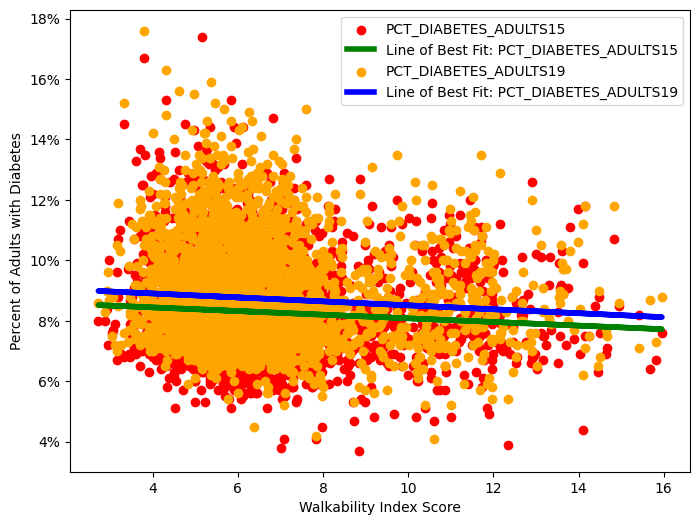

In [66]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.xlabel('Walkability Index Score')
plt.ylabel('Percent of Adults with Diabetes')
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}%'))
colors = ['red', 'green', 'orange', 'blue']
c = 0

for h in health_cols:
    x = walk_health_df[walk_health_df[h] > 0]['NatWalkInd']
    if 'DIABETES' in h:
        y = walk_health_df[walk_health_df[h] > 0][h]
        m, b = np.polyfit(x, y, 1)
        ax.scatter(x, y, label=h, color=colors[c])
        c+=1
        plt.plot(x, m*x + b, color=colors[c], linewidth=4, label=f'Line of Best Fit: {h}')
        c+=1
        plt.legend()

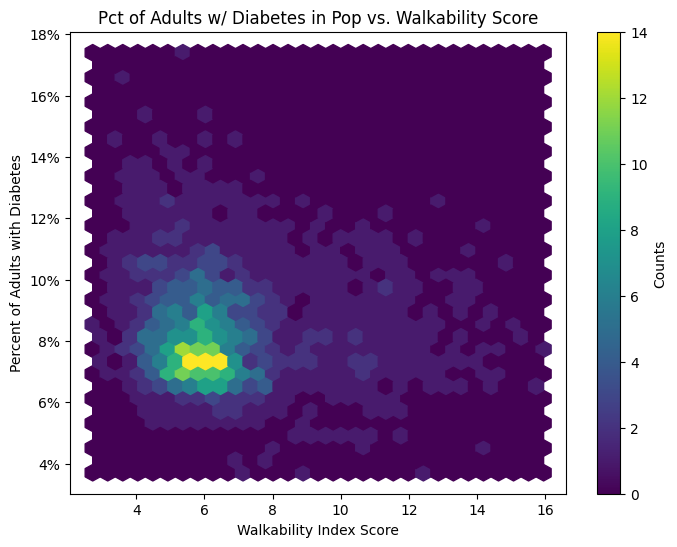

In [67]:
fig, bx = plt.subplots(figsize=(8,6))
plt.xlabel('Walkability Index Score')
plt.ylabel('Percent of Adults with Diabetes')
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}%'))
plt.title('Pct of Adults w/ Diabetes in Pop vs. Walkability Score')


for h in health_cols:
    if 'DIABETES' in h:
        hb = bx.hexbin(walk_health_df[walk_health_df[h] > 0]['NatWalkInd'], walk_health_df[walk_health_df[h] > 0][h], bins=15, gridsize=30)
        bb = fig.colorbar(hb, ax=bx)
        bb.set_label('Counts')
        plt.show()

These plots show a few things:
- There is a significantly higher density of localities which fall into the least/below average walkability categories,
- Counties with low walkability scores have a higher ceiling of reported rates of diabetes within their population, and
- Our best-fit lines show a slight downward trend of diabetes rates as walkability improves, estimating at <1% drop from worst to best walkability.

Of note, looking at the values from 2015 to 2019, it seems that overall rates of diabetes are increasing in the general population, but we still see smaller proportions of populations report diabetes as walkability increases.

Doing the same visual analysis for obesity rates vs. walkability now:

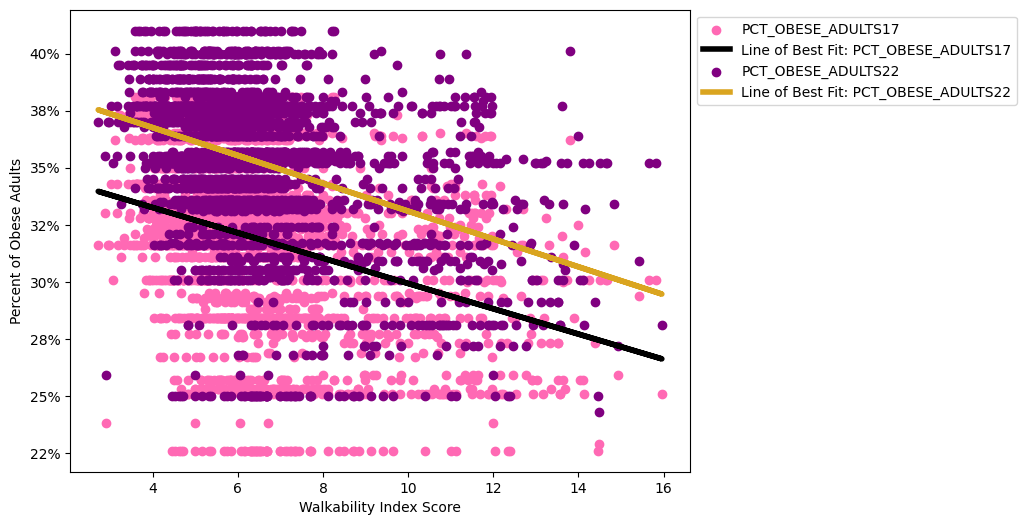

In [68]:
fig, cx = plt.subplots(figsize=(8, 6))
plt.xlabel('Walkability Index Score')
plt.ylabel('Percent of Obese Adults')
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}%'))
colors = ['hotpink', 'black', 'purple', 'goldenrod']
c = 0

for h in health_cols:
    x = walk_health_df[walk_health_df[h] > 0]['NatWalkInd']
    if 'OBESE' in h:
        y = walk_health_df[walk_health_df[h] > 0][h]
        m, b = np.polyfit(x, y, 1)
        cx.scatter(x, y, label=h, color=colors[c])
        c+=1
        plt.plot(x, m*x + b, color=colors[c], linewidth=4, label=f'Line of Best Fit: {h}')
        c+=1
        plt.legend(bbox_to_anchor=(1, 1))

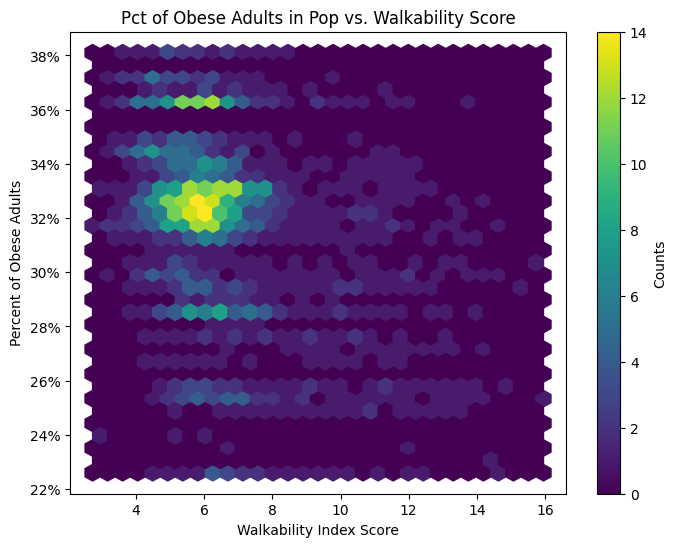

In [69]:
fig, dx = plt.subplots(figsize=(8, 6))
plt.xlabel('Walkability Index Score')
plt.ylabel('Percent of Obese Adults')
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}%'))
plt.title('Pct of Obese Adults in Pop vs. Walkability Score')

for h in health_cols:
    if 'OBESE' in h:
        pb = dx.hexbin(walk_health_df[walk_health_df[h] > 0]['NatWalkInd'], walk_health_df[walk_health_df[h] > 0][h], bins=15, label=h, gridsize=30)
        db = fig.colorbar(pb, ax=dx)
        db.set_label('Counts')
        plt.show()

The plots here tell a bit more dramatic story than the diabetes plots:

- We still see an increase over time in general rates of obesity,
- The density hotspot in these graphs is in the upper left quadrant, which represents lowest walkability and highest proportion of the population reported to be obese, and as a result,
- The best-fit lines have a much steeper slope, with ~8% less of the population being reported as obese in the most walkable counties compared to the least walkable ones.

So, our question was how will health metrics change as walkability increases?

These plots say: health metrics improve as walkability increases, and consequently deteriorate as walkability decreases. Not all health metrics are affected the same way, though, shown by the slim changes in diabetes rates vs. the steep drop in obesity rates as we looked at more walkable locations.

### **5.2:** Reflection

Given more time, I would have liked to find some additional datasets that may have filled in some gaps we found, with the biggest one being a lack of county-level (or more ideally, census block-level) obesity data. Given that our health data also carried a sense of change over time by using two years of records, it would have been nice to find/use walkability data that showed how the walkability of areas changed over time, and draw some additional conclusions about if that has an impact on the rate of change of our health metrics. There are some other aspects of walkability that would be interesting to explore as well in a separate analysis, such as car ownership and density of businesses. The United States has a much smaller pool of localities that are considered walkable by the standards of the index dataset, so that may also contribute to a sampling size issue - it could be interesting to pull similar data from European localities which tend to be less car-centric and make comparison.